<a href="https://colab.research.google.com/github/rodrigoeduardo9/Evaluacion-ConstruccionSW-GrupoLosLederes/blob/regresion-logistica/RegresionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Define the file path
file_path = '/content/hospital data analysis.csv'

try:
    # Load the dataset
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")

    # Display the first few rows and information to understand the data
    print("\nPrimeras 5 filas del dataset:")
    display(df.head())
    print("\nInformación del dataset:")
    df.info()

    # Identify the target variable
    target_variable = 'Outcome' # Changed target variable to 'Outcome'

    # Check if the target variable exists
    if target_variable not in df.columns:
        print(f"Error: La columna '{target_variable}' no se encuentra en el dataset. Por favor, verifica el nombre de la columna.")
    else:
        # Preprocessing: Handle categorical target variable if it's not numerical
        if df[target_variable].dtype == 'object':
            print(f"\nCodificando la variable objetivo '{target_variable}'.")
            le = LabelEncoder()
            df[target_variable] = le.fit_transform(df[target_variable])
            print(f"Clases codificadas: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

        # Separate features (X) and target (y)
        X = df.drop(columns=[target_variable])
        y = df[target_variable]

        # Identify and preprocess other categorical features in X
        categorical_features = X.select_dtypes(include=['object', 'category']).columns
        if not categorical_features.empty:
            print("\nRealizando One-Hot Encoding para las siguientes características categóricas:", list(categorical_features))
            X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
            print("Columnas después de One-Hot Encoding:", X.columns.tolist())
        else:
            print("\nNo se encontraron características categóricas adicionales para codificar.")

        # Handle any remaining non-numeric columns that might have been missed or are problematic
        non_numeric_cols = X.select_dtypes(exclude=['number']).columns
        if not non_numeric_cols.empty:
            print(f"Advertencia: Se encontraron columnas no numéricas que no se pudieron procesar: {list(non_numeric_cols)}. Estas serán eliminadas.")
            X = X.drop(columns=non_numeric_cols)

        # Handle missing values (simple imputation for numerical features)
        for col in X.columns:
            if X[col].isnull().any():
                if X[col].dtype in ['int64', 'float64']:
                    X[col] = X[col].fillna(X[col].mean())
                    print(f"Imputando valores nulos en la columna '{col}' con la media.")
                else:
                    print(f"Advertencia: Valores nulos encontrados en la columna no numérica '{col}' después del encoding. Estos no serán imputados por la media.")

        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        print("\nDatos divididos en conjuntos de entrenamiento y prueba.")
        print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
        print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

        # Initialize and train the Logistic Regression model
        print("\nEntrenando el modelo de Regresión Logística...")
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        print("Modelo de Regresión Logística entrenado exitosamente.")

        # Make predictions on the test set
        y_pred = model.predict(X_test)

        # Evaluate the model
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=le.classes_ if 'le' in locals() else ['0', '1'])

        print(f"\nPrecisión del modelo: {accuracy:.4f}")
        print("\nReporte de Clasificación:\n", report)

except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no se encontró. Asegúrate de que el nombre y la ruta son correctos.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Dataset loaded successfully.

Primeras 5 filas del dataset:


,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      984 non-null    int64 
 1   Age             984 non-null    int64 
 2   Gender          984 non-null    object
 3   Condition       984 non-null    object
 4   Procedure       984 non-null    object
 5   Cost            984 non-null    int64 
 6   Length_of_Stay  984 non-null    int64 
 7   Readmission     984 non-null    object
 8   Outcome         984 non-null    object
 9   Satisfaction    984 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 77.0+ KB

Codificando la variable objetivo 'Outcome'.
Clases codificadas: ['Recovered', 'Stable'] -> [0, 1]

Realizando One-Hot Encoding para las siguientes características categóricas: ['Gender', 'Condition', 'Procedure', 'Readmission']
Columnas después de One-Hot Encoding: ['Patient_ID', 'Age', '

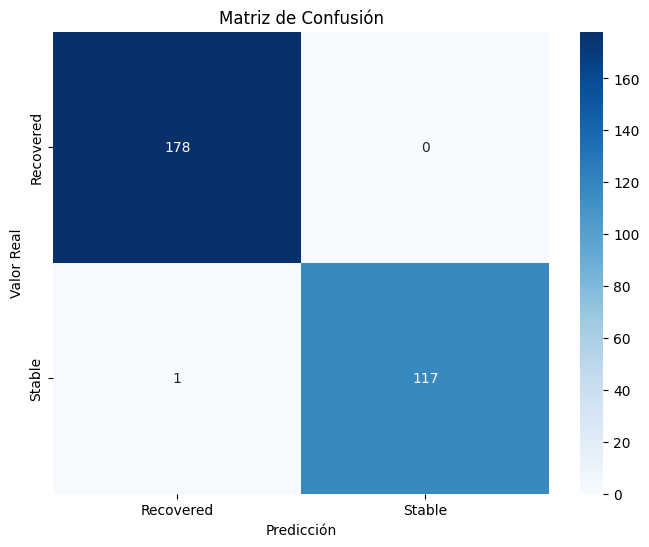

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names for better readability
# 'le' is available from the previous cell's execution context if target_variable was categorical
if 'le' in locals():
    class_names = le.classes_
else:
    class_names = ['0', '1'] # Default if not explicitly encoded or only two numeric classes

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()